# Python Project: Combating Social Media Addiction

In [342]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [344]:
# Read the students' Social Media Addiction CSV file
df = pd.read_csv(r"Students Social Media Addiction (1).csv")
# read first 5 rows from the data set
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [345]:
# Measure the total number of rows and columns in the dataset:
print(df.shape)
# find the total number of elements in dataset:
print(df.size)

(705, 13)
9165


In [348]:
# Extract the  summary of data:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

In [350]:
df.select_dtypes(include=['number']).describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


In [16]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,1,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,0,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,1,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,0,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,1,6.0,6,In Relationship,2,7


In [18]:
# Handling missing values if any available in data
# print(df.isnull())
df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

In [20]:
df.isnull().sum().sum()

0

## Exploratory Data Analysis (EDA)

* Understanding relationships between:
  * Age, Gender, Daily Usage (in hours)
  * Sleep patterns, Academic performance, and social interaction


* Analyze how addiction varies across demographics

In [25]:
# Relationship between Gender and Average use of social media.
Gender_and_use = df.groupby("Gender")["Avg_Daily_Usage_Hours"].mean()
Gender_and_use

Gender
Female    5.011048
Male      4.826136
Name: Avg_Daily_Usage_Hours, dtype: float64

In [27]:
# Relationship between Age and Daily Usage
Age_and_use = df.groupby(["Age"])["Avg_Daily_Usage_Hours"].mean().reset_index()
Age_and_use

,Age,Avg_Daily_Usage_Hours
0,18,5.385714
1,19,5.120245
2,20,4.930303
3,21,4.950641
4,22,4.676190
5,23,4.508824
6,24,5.046154


In [30]:
# Correlation between sleep hours and addiction score
Sleep_and_addicted = df[["Sleep_Hours_Per_Night", "Addicted_Score"]].corr()
Sleep_and_addicted

,Sleep_Hours_Per_Night,Addicted_Score
Sleep_Hours_Per_Night,1.000000,-0.764858
Addicted_Score,-0.764858,1.000000


In [32]:
# correlation between numerical columns 
correlation  = df[["Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night", "Addicted_Score"]].corr()
correlation

,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Addicted_Score
Avg_Daily_Usage_Hours,1.000000,-0.790582,0.832000
Sleep_Hours_Per_Night,-0.790582,1.000000,-0.764858
Addicted_Score,0.832000,-0.764858,1.000000


In [34]:
df.groupby("Country")["Addicted_Score"].sum()

Country
Afghanistan     5
Albania         7
Andorra         8
Argentina       8
Armenia         9
               ..
Uzbekistan      8
Vatican City    7
Venezuela       5
Vietnam         5
Yemen           7
Name: Addicted_Score, Length: 110, dtype: int64

In [36]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,1,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,0,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,1,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,0,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,1,6.0,6,In Relationship,2,7


## 3. Aggregation & Insights 
* Use groupby and aggregation to find average addiction level across different: 
   * Genders
   * Age Groups
   * Education levels


#### 3.1 Average addiction score by Gender

In [41]:
avg_addiction_gender = df.groupby(["Gender"])["Addicted_Score"].mean()
avg_addiction_gender

Gender
Female    6.515581
Male      6.357955
Name: Addicted_Score, dtype: float64

#### 3.2 Average addiction score by Age

In [43]:
avg_addiction_age=df.groupby(["Age"])["Addicted_Score"].mean().reset_index()
avg_addiction_age

,Age,Addicted_Score
0,18,7.785714
1,19,6.650307
2,20,6.478788
3,21,6.589744
4,22,6.095238
5,23,5.676471
6,24,6.115385


#### 3.3 Average addiction score by Academic_Level and Gender

In [173]:
avg_addiction_education=df.groupby(["Academic_Level", "Gender"])["Addicted_Score"].mean().reset_index()
avg_addiction_education

,Academic_Level,Gender,Addicted_Score
0,Graduate,Female,6.104167
1,Graduate,Male,6.267148
2,High School,Female,8.466667
3,High School,Male,7.500000
4,Undergraduate,Female,6.482759
5,Undergraduate,Male,6.539683


## 4. Functions, Loops, and Conditionals 
* Create custom functions to: 
    * Classify risk level (Low/Medium/High) based on usage hours 
    * Suggest digital detox strategies using if-else blocks 

#### 4.1 Classify risk Level based on user hours

In [176]:
# Classify risk level (Low/Medium/High) based on usage hours 
def classify_risk(hours):
    if hours < 2:
        return "Low"
    elif 2 <= hours < 4:
        return "Medium"
    else:
        return "High"


In [354]:
df["Risk_Level"]= df["Avg_Daily_Usage_Hours"].apply(classify_risk)
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score,Risk_Level
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8,High
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3,Medium
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9,High
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4,Medium
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7,High


#### 4.2 Digital detox strategies

In [356]:
# Suggest digital detox strategies
def detox_strategy(risk):
    if risk == "High":
        return "strict detox: Limit usage to under 1 hour and avoid social media 2 days a week."
    elif risk == "Medium":
        return "Moderate detox: Reduce usage by half and follow a screen-free hour before bed"
    else:
        return "Maintain healthy habits and monitor usage regularly."
        

In [358]:
df["detox_strategy"]=df["Risk_Level"].apply(detox_strategy)
(df.head())

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score,Risk_Level,detox_strategy
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8,High,strict detox: Limit usage to under 1 hour and ...
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3,Medium,Moderate detox: Reduce usage by half and follo...
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9,High,strict detox: Limit usage to under 1 hour and ...
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4,Medium,Moderate detox: Reduce usage by half and follo...
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7,High,strict detox: Limit usage to under 1 hour and ...


## 5. Data Visualization 

* Use at least 4 different types of visualizations: 
    * Bar chart, Pie chart, Heatmap, Line plot, etc. 
* Each chart must include: 
    * Clear title, labeled axes 
    * A short written story/insight below the chart (1–2 lines) 

In [363]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## (1) Line Plot

#### 5.1 Average Addiction Score by Age and Gender

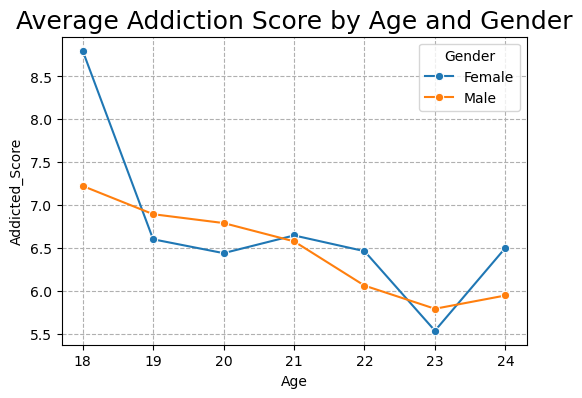

In [411]:

# Step 1: Group and reset index to make it a DataFrame
Age_gender = df.groupby(["Age", "Gender"])["Addicted_Score"].mean().reset_index()

# Step 2: Plot the trend
plt.figure(figsize=(6,4))
sns.lineplot(data=Age_gender, x="Age", y="Addicted_Score", hue="Gender", marker="o")
plt.title("Average Addiction Score by Age and Gender", fontsize = 18)
plt.grid(linestyle = "--")
plt.show()


##### "Female students have higher addiction risks at a younger age, with both genders showing lower scores as they get older."
##### "The both gender are different over time points to change media behaviours and priorities with age"

## Bar Chart 

#### 5.2 Average use of different social media platforms

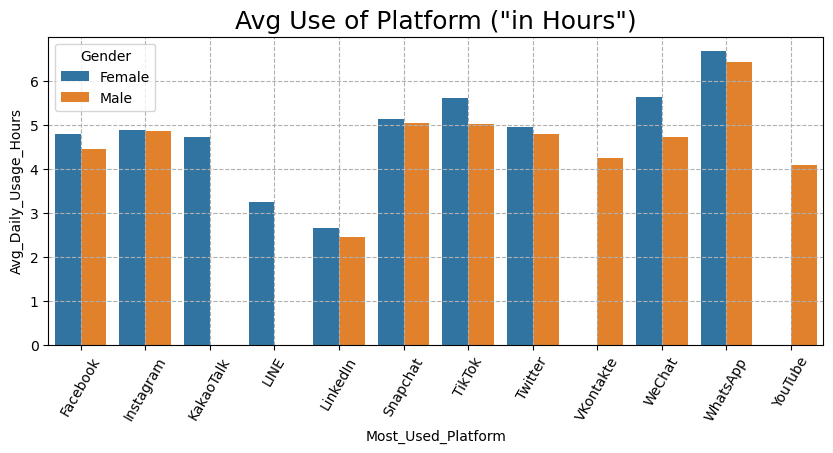

In [413]:
users =df.groupby(["Most_Used_Platform", "Gender"])['Avg_Daily_Usage_Hours'].mean().reset_index()

# Step 2: Plot the trend
plt.figure(figsize=(10,4))
sns.barplot(data=users, x="Most_Used_Platform", y='Avg_Daily_Usage_Hours',  hue = "Gender")
plt.title('Avg Use of Platform ("in Hours")', fontsize = 18)
plt.grid(linestyle = "--")
plt.xticks(rotation = 60)
plt.show()

##### "WhatsApp stands out as the Avg_most used platform by genders, with females using its slightly more than males.
##### "Females generally spend more time per day on nearly all platforms except YouTube, where male lead in usage.
      

# Pie Chart

#### 5.3   Top 5 social media platforms 

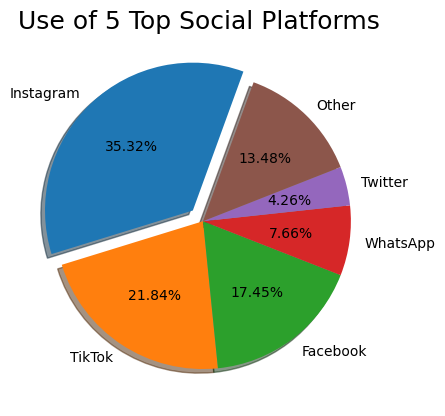

In [415]:
# Extract the most use platforms with count vlaues
platform_counts = df["Most_Used_Platform"].value_counts()

# Get top 5 platforms
top_5 = platform_counts.head(5)

# sum the counts of all remaining platforms
others = platform_counts[5: ].sum()

final_platform = pd.concat([top_5, pd.Series({"Other": others})])

# create a pie chart to present the top 5 platforms
plt.pie(final_platform, labels=final_platform.index,
        startangle = 70, shadow = True,
       autopct = "%1.2f%%", explode = [0.1,0,0,0,0,0])
plt.title("Use of 5 Top Social Platforms ", fontsize = 18)
plt.show()

##### Out of the 5 top social media platforms, Instagram is one of the most used platforms.
##### Instagram captures around 36 percent of users.

## Heatmap

#### 5.4 Heatmap presents the correlation and coefficient in data columns 

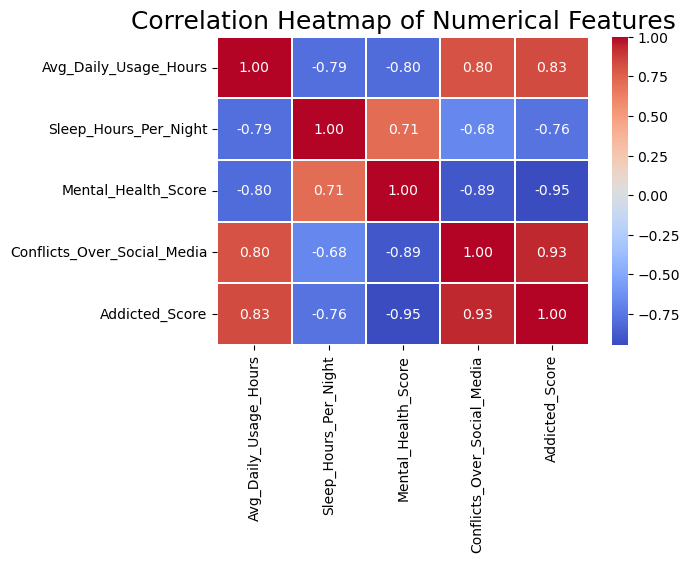

In [417]:
# Selecting numerical columns from the dataset for Heatmap.
num_df = df[["Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night", "Mental_Health_Score", 'Conflicts_Over_Social_Media', "Addicted_Score" ]]

# Compute correlation matrix
corr = num_df.corr()

# Create heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm',
            linewidths=1.1, fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features", fontsize=18)
plt.show()

##### Strong positive correlation 
* Overuse of social media trends to increase both eddiction and online conflicts
##### Strong Negative Correlation
*  Increased addiction and conflicts strongly harm mental health and reduce sleep quality

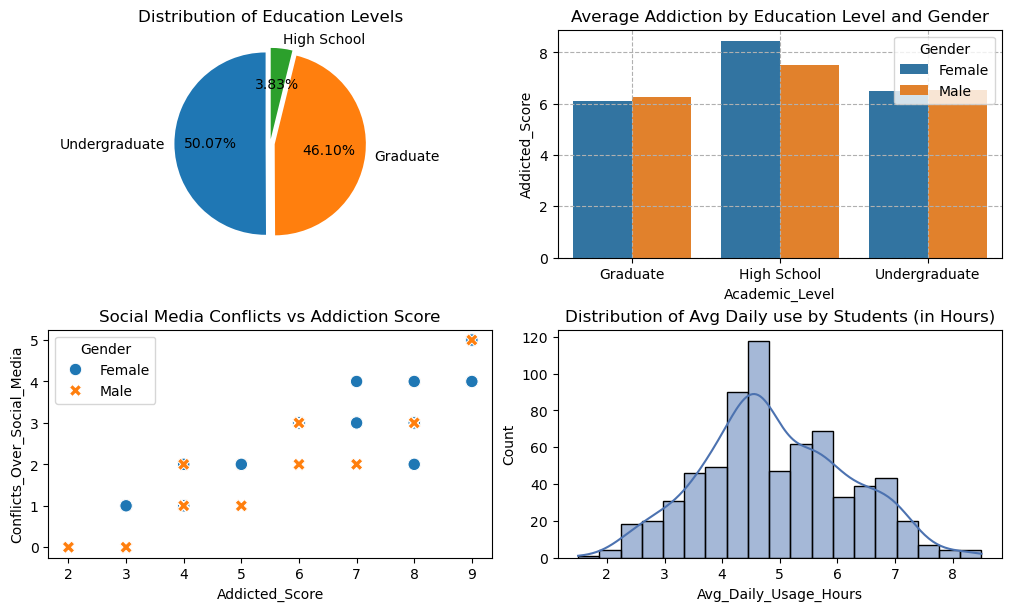

In [392]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(10,6), layout="constrained")

# ----- Pie Chart -----
Education = df["Academic_Level"].value_counts()
explode = [0.05] * len(Education)

axes[0,0].pie(Education, labels=Education.index, autopct='%1.2f%%', 
               startangle=90, explode=explode)
axes[0,0].set_title("Distribution of Education Levels")
axes[0,0].set_ylabel("")

# ----- Bar Chart -----
sns.barplot(data=avg_addiction_education, 
            x="Academic_Level", 
            y="Addicted_Score", 
            hue="Gender", 
            ax=axes[0,1])
axes[0,1].set_title("Average Addiction by Education Level and Gender")
axes[0,1].grid(linestyle="--")

# ----- Scatter Plot -----
sns.scatterplot(data=df, 
                x="Addicted_Score", 
                y="Conflicts_Over_Social_Media", 
                hue="Gender", 
                style="Gender", 
                s=80, 
                ax=axes[1,0])
axes[1,0].set_title("Social Media Conflicts vs Addiction Score")

# ----- Histogram -----
sns.histplot(df["Avg_Daily_Usage_Hours"],color = "#4C72B0" ,kde = True, ax=axes[1,1])
axes[1,1].set_title("Distribution of Avg Daily use by Students (in Hours)")
plt.show()


## 6. Storytelling Deliverable 

In [352]:
story_summary = """
Key patterns found include higher addiction levels among younger students and males.

High daily usage negatively impacts sleep and academic performance.

Addiction varies significantly across education levels, with undergraduates more at risk.

Root causes include easy access, peer pressure, and lack of self-regulation.
the risk classification helps in personalizing intervention strategies.

Digital detox strategies range from strict to moderate, depending on risk level.

Visualizations reveal clear demographic trends and correlations to addictive behavior.

Recommendations include awareness campaigns, digital detox programs, and counseling support.

Future work may include longitudinal studies and app usage tracking.
This data-driven approach provides actionable insights for educators and parents.

"""

print(story_summary)


Key patterns found include higher addiction levels among younger students and males.

High daily usage negatively impacts sleep and academic performance.

Addiction varies significantly across education levels, with undergraduates more at risk.

Root causes include easy access, peer pressure, and lack of self-regulation.
the risk classification helps in personalizing intervention strategies.

Digital detox strategies range from strict to moderate, depending on risk level.

Visualizations reveal clear demographic trends and correlations to addictive behavior.

Recommendations include awareness campaigns, digital detox programs, and counseling support.

Future work may include longitudinal studies and app usage tracking.
This data-driven approach provides actionable insights for educators and parents.


